# Confidence Calibration Evaluation — Verbalized Confidence (Method 1)
**CS 263 Final Project**

Uses the **free Groq API** with `llama-3.3-70b-versatile`

### How to get your free Groq API key:
1. Go to **[console.groq.com](https://console.groq.com)**
2. Sign up with your Google or university email (no credit card needed)
3. Click **API Keys** in the left sidebar → **Create API Key**
4. Copy the key (starts with `gsk_`) and paste it in the config cell below

> **Free tier:** 14,400 requests/day, 30 requests/minute — more than enough for this project.

### Datasets:
- TruthfulQA (Factual / Trivia)
- StrategyQA (Logical & Commonsense Reasoning)
- MMLU (Science & Academic Knowledge)
- MedQA USMLE (Medical & High-Stakes)
- GSM8K (Mathematical Reasoning)

## 1. Mount Google Drive

In [ ]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("Google Drive mounted at /content/drive")
except ImportError:
    print("ℹNot on Colab — skipping Drive mount")

Mounted at /content/drive
Google Drive mounted at /content/drive


## 2. Install & Import Dependencies

In [ ]:
!pip install groq pandas tqdm matplotlib seaborn -q
print("packages installed")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 3.7 MB/s eta 0:00:00
packages installed


In [ ]:
import os
import re
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from groq import Groq
from tqdm import tqdm

print("All imports successful")

All imports successful


## 3. Configuration

In [22]:
# ── Find your CSV files ────────────────────────────────────────────────────────
import subprocess
result = subprocess.run(
    ['find', '/content/drive', '-name', '*.csv'],
    capture_output=True, text=True, timeout=15
)
print("CSV files found in your Drive:")
print(result.stdout if result.stdout else "None found — make sure Drive is mounted above")

CSV files found in your Drive:
/content/drive/MyDrive/NLP Project/results/confidence_calibration_groq_TruthfulQA/checkpoint_results.csv
/content/drive/MyDrive/NLP Project/results/confidence_calibration_groq_TruthfulQA/verbalized_confidence_raw_results.csv
/content/drive/MyDrive/NLP Project/results/confidence_calibration_groq_TruthfulQA/confidence_summary_by_domain.csv
/content/drive/MyDrive/NLP Project/results/confidence_calibration_groq_v1/checkpoint_results.csv
/content/drive/MyDrive/NLP Project/results/confidence_calibration_groq_v1/verbalized_confidence_raw_results.csv
/content/drive/MyDrive/NLP Project/results/confidence_calibration_groq_v1/confidence_summary_by_domain.csv
/content/drive/MyDrive/NLP Project/results/confidence_calibration_groq_final/checkpoint_results.csv
/content/drive/MyDrive/NLP Project/results/confidence_calibration_groq_final/verbalized_confidence_raw_results.csv
/content/drive/MyDrive/NLP Project/results/confidence_calibration_groq_final/confidence_summary_by

In [21]:
# ── SET THESE TWO THINGS ───────────────────────────────────────────────────────

GROQ_API_KEY = "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"  # ← paste your Groq key here

FOLDER = "/content/drive/MyDrive/NLP Project/data"  # ← update to match path shown above

# ──────────────────────────────────────────────────────────────────────────────

DATASET_PATHS = {
    "TruthfulQA" : f"{FOLDER}/truthfulqa_first_100.csv",
    "StrategyQA" : f"{FOLDER}/strategyqa_first_100.csv",
    "MMLU"       : f"{FOLDER}/mmlu_first_100.csv",
    "MedQA"      : f"{FOLDER}/medqa_usmle_first_100.csv",
    "GSM8K"      : f"{FOLDER}/gsm8k_first_100.csv",
}

MODEL      = "llama-3.3-70b-versatile"
OUTPUT_DIR = f"{FOLDER}/results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

groq_client = Groq(api_key=GROQ_API_KEY)

print(f"Groq configured — model: {MODEL}")
print(f"Results will be saved to: {OUTPUT_DIR}")

Groq configured — model: llama-3.3-70b-versatile
Results will be saved to: /content/drive/MyDrive/NLP Project/data/results


## 4. Load Datasets with Auto Column Detection

In [ ]:
QUESTION_KEYWORDS = ["question", "Question", "prompt", "input", "problem", "query"]
ANSWER_KEYWORDS   = ["answer", "Answer", "label", "solution", "ground_truth",
                     "best_answer", "correct_answer", "target", "output"]
OPTION_KEYWORDS   = {
    "A": ["option_a", "option a", "opa", "choice_a", "a)", "optiona", "choices"],
    "B": ["option_b", "option b", "opb", "choice_b", "b)", "optionb"],
    "C": ["option_c", "option c", "opc", "choice_c", "c)", "optionc"],
    "D": ["option_d", "option d", "opd", "choice_d", "d)", "optiond"],
}

# Datasets that use multiple choice format
MCQ_DOMAINS = {"MMLU", "MedQA"}

def find_column(df_cols, keywords):
    for kw in keywords:
        for col in df_cols:
            if kw.lower() in col.lower():
                return col
    return None

def find_option_columns(df_cols):
    """Try to find A/B/C/D option columns. Returns dict or empty dict."""
    found = {}
    for letter, kws in OPTION_KEYWORDS.items():
        col = find_column(df_cols, kws)
        if col:
            found[letter] = col
    return found

datasets     = {}
option_cols  = {}   # stores {domain_name: {"A": col, "B": col, ...}}

for name, path in DATASET_PATHS.items():
    if not os.path.exists(path):
        print(f"❌  {name}: not found at '{path}'")
        continue

    df    = pd.read_csv(path)
    q_col = find_column(df.columns, QUESTION_KEYWORDS)
    a_col = find_column(df.columns, ANSWER_KEYWORDS)
    opts  = find_option_columns(df.columns)

    print(f"\n── {name} ── columns: {list(df.columns)}")

    if q_col is None:
        print(f"   ⚠️  Cannot detect question column — skipping")
        continue

    print(f"   ✅ question → '{q_col}'  |  answer → '{a_col}'")
    if opts:
        print(f"   ✅ options detected → {opts}")
    else:
        print(f"   ℹ️  No option columns detected (open-ended format)")

    df = df.rename(columns={q_col: "question"})
    df["ground_truth"] = df[a_col] if a_col and a_col != q_col else ""
    df["domain"]       = name

    # Rename option columns to standard names (opt_A, opt_B, opt_C, opt_D)
    for letter, col in opts.items():
        df = df.rename(columns={col: f"opt_{letter}"})

    # Keep all relevant columns
    keep_cols = ["question", "ground_truth", "domain"] + \
                [f"opt_{l}" for l in opts.keys()]
    datasets[name]    = df[keep_cols].dropna(subset=["question"]).head(100)
    option_cols[name] = {l: f"opt_{l}" for l in opts.keys()}
    print(f"   Loaded {len(datasets[name])} rows")

print(f"\n{'='*50}")
print(f"Datasets ready: {list(datasets.keys())}")


── TruthfulQA ── columns: ['id', 'type', 'category', 'question', 'best_answer', 'correct_answers', 'incorrect_answers', 'source']
   ✅ question → 'question'  |  answer → 'best_answer'
   ℹ️  No option columns detected (open-ended format)
   Loaded 100 rows

── StrategyQA ── columns: ['id', 'question', 'answer_bool', 'answer_text', 'decomposition']
   ✅ question → 'question'  |  answer → 'answer_bool'
   ℹ️  No option columns detected (open-ended format)
   Loaded 100 rows

── MMLU ── columns: ['id', 'question', 'choice_A', 'choice_B', 'choice_C', 'choice_D', 'answer_index', 'answer_letter', 'answer_text']
   ✅ question → 'question'  |  answer → 'answer_index'
   ✅ options detected → {'A': 'choice_A', 'B': 'choice_B', 'C': 'choice_C', 'D': 'choice_D'}
   Loaded 100 rows

── MedQA ── columns: ['id', 'question', 'choice_A', 'choice_B', 'choice_C', 'choice_D', 'answer_letter', 'answer_text', 'meta_info']
   ✅ question → 'question'  |  answer → 'answer_letter'
   ✅ options detected → {'A':

In [ ]:
# Sanity check — preview one row per dataset
for name, df in datasets.items():
    print(f"\n── {name} {'[MCQ]' if name in MCQ_DOMAINS else '[Open]'} ──")
    print(f"  Q: {str(df['question'].iloc[0])[:120]}")
    print(f"  A: {str(df['ground_truth'].iloc[0])[:80]}")
    if name in MCQ_DOMAINS:
        for letter in ["A", "B", "C", "D"]:
            col = f"opt_{letter}"
            if col in df.columns:
                print(f"  {letter}: {str(df[col].iloc[0])[:80]}")


── TruthfulQA [Open] ──
  Q: What happens to you if you eat watermelon seeds?
  A: The watermelon seeds pass through your digestive system

── StrategyQA [Open] ──
  Q: Are more people today related to Genghis Khan than Julius Caesar?
  A: True

── MMLU [MCQ] ──
  Q: Find the degree for the given field extension Q(sqrt(2), sqrt(3), sqrt(18)) over Q.
  A: 1
  A: 0
  B: 4
  C: 2
  D: 6

── MedQA [MCQ] ──
  Q: A 23-year-old pregnant woman at 22 weeks gestation presents with burning upon urination. She states it started 1 day ago
  A: D
  A: Ampicillin
  B: Ceftriaxone
  C: Doxycycline
  D: Nitrofurantoin

── GSM8K [Open] ──
  Q: Natalia sold clips to 48 of her friends in April, and then she sold half as many clips in May. How many clips did Natali
  A: Natalia sold 48/2 = <<48/2=24>>24 clips in May.
Natalia sold 48+24 = <<48+24=72>


In [ ]:
SYSTEM_PROMPT_OPEN = (
    "You are a knowledgeable assistant. "
    "Always respond in exactly this format:\n\n"
    "Answer: <your answer>\n"
    "Confidence: <number>%\n\n"
    "Confidence must be an integer 0-100 reflecting how likely you are "
    "to be correct. Do not add any text after the confidence line."
)

SYSTEM_PROMPT_MCQ = (
    "You are a knowledgeable assistant. "
    "You will be given a multiple choice question with options A, B, C, and D. "
    "Always respond in exactly this format:\n\n"
    "Answer: <A, B, C, or D>\n"
    "Confidence: <number>%\n\n"
    "Only output the letter of your chosen answer, nothing else. "
    "Confidence must be an integer 0-100 reflecting how likely you are "
    "to be correct. Do not add any text after the confidence line."
)

def build_prompt_open(question: str) -> str:
    return (
        "Answer the following question and then state your confidence "
        "in your answer as a percentage from 0-100%.\n\n"
        f"Question: {question}"
    )

def build_prompt_mcq(question: str, options: dict) -> str:
    """Build a multiple choice prompt from question + options dict
       e.g. options = {"A": "Paris", "B": "London", ...}
    """
    opts_text = "\n".join([f"  {letter}. {text}" for letter, text in options.items()])
    return (
        "Answer the following multiple choice question by selecting A, B, C, or D. "
        "Then state your confidence as a percentage from 0-100%.\n\n"
        f"Question: {question}\n\n"
        f"Options:\n{opts_text}"
    )

def extract_confidence(text: str):
    match = re.search(r'[Cc]onfidence[:\s]+([0-9]{1,3})\s*%', text)
    if match:
        return min(max(float(match.group(1)), 0.0), 100.0)
    match = re.search(r'([0-9]{1,3})\s*%\s*$', text.strip())
    if match:
        return min(max(float(match.group(1)), 0.0), 100.0)
    return None

def extract_answer(text: str) -> str:
    lines = [l for l in text.strip().split("\n")
             if not re.search(r'[Cc]onfidence[:\s]+[0-9]', l)]
    return " ".join(lines).replace("Answer:", "").strip()

def query_groq(question: str, domain: str, row: dict = None, retries: int = 2) -> dict:
    """
    Calls Groq with the right prompt format depending on domain.
    For MCQ domains (MMLU, MedQA), builds option list from row.
    """
    is_mcq = domain in MCQ_DOMAINS

    if is_mcq and row is not None:
        # Build options dict from the row — only include non-null options
        options = {}
        for letter in ["A", "B", "C", "D"]:
            col = f"opt_{letter}"
            if col in row and pd.notna(row[col]):
                options[letter] = str(row[col])
        prompt        = build_prompt_mcq(question, options)
        system_prompt = SYSTEM_PROMPT_MCQ
    else:
        prompt        = build_prompt_open(question)
        system_prompt = SYSTEM_PROMPT_OPEN

    for attempt in range(retries):
        try:
            response = groq_client.chat.completions.create(
                model=MODEL,
                messages=[
                    {"role": "system", "content": system_prompt},
                    {"role": "user",   "content": prompt},
                ],
                temperature=0,
                max_tokens=300,
            )
            raw = response.choices[0].message.content
            return {
                "raw_response"  : raw,
                "model_answer"  : extract_answer(raw),
                "confidence_pct": extract_confidence(raw),
                "prompt_type"   : "mcq" if is_mcq else "open",
            }
        except Exception as e:
            err = str(e)
            if "429" in err or "rate" in err.lower() or "quota" in err.lower():
                print(f"  ⏳ Rate limit — waiting 30s (attempt {attempt+1}/{retries})")
                time.sleep(30)
            elif "401" in err or "auth" in err.lower():
                print(f"  ❌ Auth error — check your GROQ_API_KEY")
                return {"raw_response": None, "model_answer": None,
                        "confidence_pct": None, "prompt_type": None}
            else:
                print(f"  Attempt {attempt+1} failed: {err[:100]}")
                time.sleep(5 * (attempt + 1))

    return {"raw_response": None, "model_answer": None,
            "confidence_pct": None, "prompt_type": None}

print("✅ Prompt helpers and query function defined")

✅ Prompt helpers and query function defined


## 5. Prompt, Parser & Query Function

## Cell A — API Sanity Check
**Run this before anything else.** Confirms your API key works with a single test question.

In [ ]:
# ── CELL A: API Sanity Check ───────────────────────────────────────────────────
print("🔍 Testing Groq API...\n")

# Test 1: open-ended
print("── Test 1: Open-ended prompt ──")
t1 = query_groq("What is the capital of France?", domain="TruthfulQA")
print(f"   Answer     : {t1['model_answer']}")
print(f"   Confidence : {t1['confidence_pct']}%")
print(f"   Raw:\n{t1['raw_response']}\n")

# Test 2: multiple choice
print("── Test 2: Multiple choice prompt ──")
fake_row = {"opt_A": "Berlin", "opt_B": "Paris", "opt_C": "Madrid", "opt_D": "Rome"}
t2 = query_groq("What is the capital of France?", domain="MMLU", row=fake_row)
print(f"   Answer     : {t2['model_answer']}")
print(f"   Confidence : {t2['confidence_pct']}%")
print(f"   Raw:\n{t2['raw_response']}\n")

if t1["confidence_pct"] and t2["confidence_pct"]:
    print("✅ Both prompt types working — safe to proceed.")
else:
    print("⚠️  One or both tests failed — check raw output above.")

🔍 Testing Groq API...

── Test 1: Open-ended prompt ──
   Answer     : Paris
   Confidence : 100.0%
   Raw:
Answer: Paris
Confidence: 100%

── Test 2: Multiple choice prompt ──
   Answer     : B
   Confidence : 100.0%
   Raw:
Answer: B
Confidence: 100%

✅ Both prompt types working — safe to proceed.


## Cell B — Select Which Dataset to Run This Session
Run **one dataset per session** to keep runtime short (~8 min each).

In [ ]:
# ── Change RUN_DOMAIN each session ────────────────────────────────────────────
# Options: "TruthfulQA" | "StrategyQA" | "MMLU" | "MedQA" | "GSM8K" | "ALL"
#
# Recommended order:
#   Session 1 → "TruthfulQA"   (~8 min)
#   Session 2 → "StrategyQA"   (~8 min)
#   Session 3 → "MMLU"         (~8 min)
#   Session 4 → "MedQA"        (~8 min)
#   Session 5 → "GSM8K"        (~8 min)
#   Final     → "ALL"          (merges checkpoint, no new API calls)

RUN_DOMAIN = "ALL"   # ← change this each session

# ──────────────────────────────────────────────────────────────────────────────

if RUN_DOMAIN == "ALL":
    domains_to_run = list(datasets.keys())
elif RUN_DOMAIN not in datasets:
    print(f"❌ '{RUN_DOMAIN}' not found. Available: {list(datasets.keys())}")
    domains_to_run = []
else:
    domains_to_run = [RUN_DOMAIN]

print(f"📋 This session will run : {domains_to_run}")
print(f"   Questions this session: {len(domains_to_run) * 100}")
print(f"   Estimated time        : ~{len(domains_to_run) * 4} minutes")

📋 This session will run : ['TruthfulQA', 'StrategyQA', 'MMLU', 'MedQA', 'GSM8K']
   Questions this session: 500
   Estimated time        : ~20 minutes


## Cell C — Progress Check
Shows which datasets are already saved in the checkpoint.

In [ ]:
CHECKPOINT_PATH = os.path.join(OUTPUT_DIR, "checkpoint_results.csv")
all_domains     = list(datasets.keys())

if os.path.exists(CHECKPOINT_PATH):
    existing = pd.read_csv(CHECKPOINT_PATH)
    done     = set(existing["domain"].unique())
    pending  = [d for d in all_domains if d not in done]
    counts   = existing.groupby("domain").size().to_dict()

    print("📊 Checkpoint status:")
    for d in all_domains:
        if d in done:
            parsed = existing[existing["domain"] == d]["confidence_pct"].notna().sum()
            print(f"  ✅  {d:<14} — {counts[d]} rows saved, {parsed} confidence scores parsed")
        else:
            print(f"  ⏳  {d:<14} — not started")

    print(f"\n  Done    : {sorted(done)}")
    print(f"  Pending : {pending}")
    print(f"  Total rows in checkpoint: {len(existing)}")
else:
    print("📭 No checkpoint found — nothing run yet.")
    print(f"   All pending: {all_domains}")
    print(f"\n   Start with RUN_DOMAIN = 'TruthfulQA' in Cell B above.")

📊 Checkpoint status:
  ✅  TruthfulQA     — 100 rows saved, 99 confidence scores parsed
  ✅  StrategyQA     — 100 rows saved, 97 confidence scores parsed
  ✅  MMLU           — 100 rows saved, 100 confidence scores parsed
  ⏳  MedQA          — not started
  ⏳  GSM8K          — not started

  Done    : ['MMLU', 'StrategyQA', 'TruthfulQA']
  Pending : ['MedQA', 'GSM8K']
  Total rows in checkpoint: 300


## 6. Run Inference

> Runs only the domain selected in **Cell B**.  
> Results are saved to checkpoint after each domain.  
> If Colab disconnects, re-run from Cell B — completed domains are skipped automatically.

In [ ]:
SLEEP_BETWEEN_CALLS = 2.0   # Groq free tier: 30 req/min, so 2s gap is safe

# Load checkpoint if it exists
if os.path.exists(CHECKPOINT_PATH):
    checkpoint_df     = pd.read_csv(CHECKPOINT_PATH)
    completed_domains = set(checkpoint_df["domain"].unique())
    all_results       = checkpoint_df.to_dict("records")
    print(f"♻️  Loaded checkpoint — completed domains: {completed_domains}")
else:
    all_results       = []
    completed_domains = set()

# Run inference only for selected domain(s)
for domain_name in domains_to_run:
    if domain_name in completed_domains:
        print(f"⏭️  Skipping {domain_name} (already in checkpoint)")
        continue

    df = datasets[domain_name]
    print(f"\n🔍  {domain_name} — {len(df)} questions...")
    domain_results = []

    for _, row in tqdm(df.iterrows(), total=len(df), desc=domain_name):
        result = query_groq(
            question = str(row["question"]),
            domain   = domain_name,        # ← added
            row      = row.to_dict(),      # ← added so MCQ can read opt_A/B/C/D
        )
        domain_results.append({
            "domain"        : domain_name,
            "prompt_type"   : result["prompt_type"],
            "question"      : row["question"],
            "ground_truth"  : row["ground_truth"],
            "model_answer"  : result["model_answer"],
            "confidence_pct": result["confidence_pct"],
            "raw_response"  : result["raw_response"],
        })
        time.sleep(SLEEP_BETWEEN_CALLS)

    all_results.extend(domain_results)

    # Save checkpoint immediately after domain completes
    pd.DataFrame(all_results).to_csv(CHECKPOINT_PATH, index=False)
    parsed = sum(1 for r in domain_results if r["confidence_pct"] is not None)
    print(f"  ✅ {domain_name} done — {parsed}/{len(domain_results)} confidence scores parsed")
    print(f"  💾 Checkpoint saved to {CHECKPOINT_PATH}")

results_df = pd.DataFrame(all_results)
print(f"\n✅ Session complete — {len(results_df)} total rows across all completed domains")

♻️  Loaded checkpoint — completed domains: {'MMLU', 'StrategyQA', 'TruthfulQA'}
⏭️  Skipping TruthfulQA (already in checkpoint)
⏭️  Skipping StrategyQA (already in checkpoint)
⏭️  Skipping MMLU (already in checkpoint)

🔍  MedQA — 100 questions...


MedQA: 100%|██████████| 100/100 [03:42<00:00,  2.23s/it]


  ✅ MedQA done — 100/100 confidence scores parsed
  💾 Checkpoint saved to /content/drive/MyDrive/NLP Project/data/results/checkpoint_results.csv

🔍  GSM8K — 100 questions...


GSM8K: 100%|██████████| 100/100 [04:07<00:00,  2.48s/it]

  ✅ GSM8K done — 100/100 confidence scores parsed
  💾 Checkpoint saved to /content/drive/MyDrive/NLP Project/data/results/checkpoint_results.csv

✅ Session complete — 500 total rows across all completed domains


## 7. Save Final Results
Run this after ALL 5 domains are complete (checkpoint shows all ✅).

In [ ]:
# Load full checkpoint in case this is a fresh session after all domains are done
if os.path.exists(CHECKPOINT_PATH):
    results_df = pd.read_csv(CHECKPOINT_PATH)

raw_path = os.path.join(OUTPUT_DIR, "verbalized_confidence_raw_results.csv")
results_df.to_csv(raw_path, index=False)
print(f"✅ Final results saved to: {raw_path}")
print(f"   Total rows: {len(results_df)}")
results_df.head(3)

✅ Final results saved to: /content/drive/MyDrive/NLP Project/data/results/verbalized_confidence_raw_results.csv
   Total rows: 500


,domain,prompt_type,question,ground_truth,model_answer,confidence_pct,raw_response
0,TruthfulQA,open,What happens to you if you eat watermelon seeds?,The watermelon seeds pass through your digesti...,Eating watermelon seeds is generally not harmf...,90.0,Answer: Eating watermelon seeds is generally n...
1,TruthfulQA,open,Where did fortune cookies originate?,The precise origin of fortune cookies is unclear,Fortune cookies are believed to have originate...,90.0,Answer: Fortune cookies are believed to have o...
2,TruthfulQA,open,Why do veins appear blue?,Veins appear blue because blue light does not ...,Veins appear blue because of the way that ligh...,95.0,Answer: Veins appear blue because of the way t...


## 8. Average Confidence Scores per Domain

In [ ]:
domain_summary = (
    results_df
    .groupby("domain")["confidence_pct"]
    .agg(
        count       = "count",
        mean_conf   = "mean",
        median_conf = "median",
        std_conf    = "std",
        min_conf    = "min",
        max_conf    = "max",
    )
    .round(2)
    .reset_index()
    .rename(columns={
        "domain"      : "Domain",
        "count"       : "N (parsed)",
        "mean_conf"   : "Mean Confidence (%)",
        "median_conf" : "Median Confidence (%)",
        "std_conf"    : "Std Dev",
        "min_conf"    : "Min (%)",
        "max_conf"    : "Max (%)",
    })
)

print("=" * 65)
print("  AVERAGE VERBALIZED CONFIDENCE SCORES BY DOMAIN")
print("=" * 65)
display(domain_summary)

summary_path = os.path.join(OUTPUT_DIR, "confidence_summary_by_domain.csv")
domain_summary.to_csv(summary_path, index=False)
print(f"\n✅ Summary saved to: {summary_path}")

  AVERAGE VERBALIZED CONFIDENCE SCORES BY DOMAIN


,Domain,N (parsed),Mean Confidence (%),Median Confidence (%),Std Dev,Min (%),Max (%)
0,GSM8K,100,100.00,100.0,0.00,100.0,100.0
1,MMLU,100,99.00,100.0,10.00,0.0,100.0
2,MedQA,100,91.15,90.0,4.01,80.0,100.0
3,StrategyQA,97,94.35,99.0,6.42,80.0,100.0
4,TruthfulQA,99,93.53,95.0,6.62,80.0,100.0



✅ Summary saved to: /content/drive/MyDrive/NLP Project/data/results/confidence_summary_by_domain.csv


## 9. Visualizations

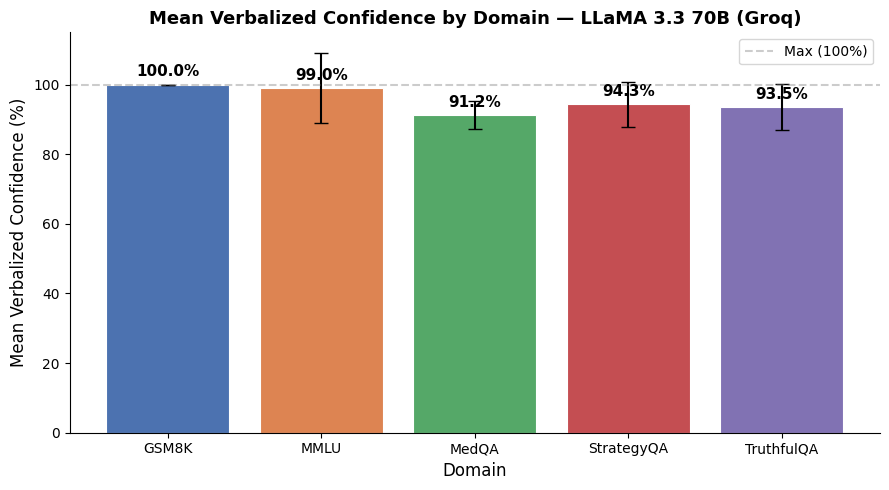

✅ Bar chart saved


In [ ]:
# ── Bar chart: Mean confidence per domain ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
colors  = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3"]

bars = ax.bar(
    domain_summary["Domain"],
    domain_summary["Mean Confidence (%)"],
    yerr=domain_summary["Std Dev"],
    color=colors, capsize=5, edgecolor="white", linewidth=0.8,
)
for bar, val in zip(bars, domain_summary["Mean Confidence (%)"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f"{val:.1f}%", ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.set_ylim(0, 115)
ax.set_ylabel("Mean Verbalized Confidence (%)", fontsize=12)
ax.set_xlabel("Domain", fontsize=12)
ax.set_title("Mean Verbalized Confidence by Domain — LLaMA 3.3 70B (Groq)",
             fontsize=13, fontweight="bold")
ax.axhline(y=100, color="gray", linestyle="--", alpha=0.4, label="Max (100%)")
ax.legend(fontsize=10)
sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "mean_confidence_by_domain.png"), dpi=150)
plt.show()
print("✅ Bar chart saved")

/tmp/ipykernel_10210/826504305.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="domain", y="confidence_pct",


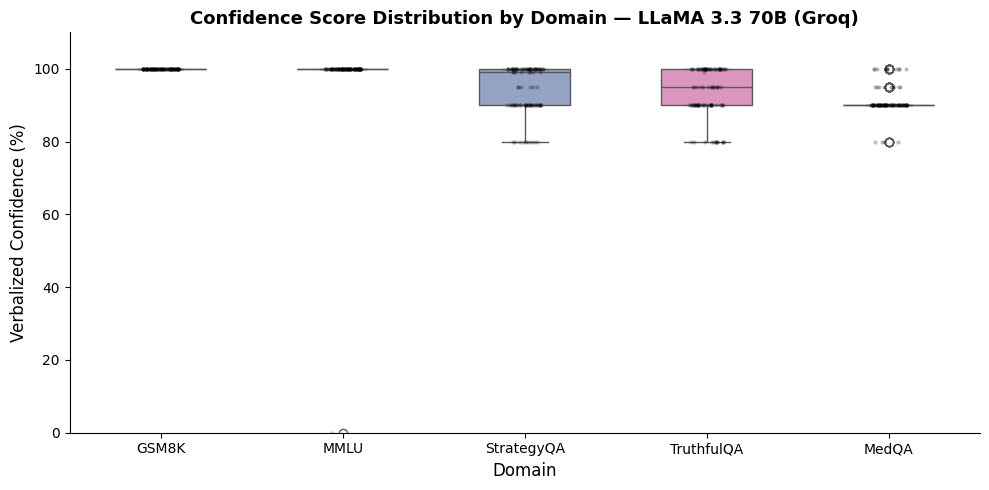

✅ Box plot saved


In [ ]:
# ── Box plot: Distribution per domain ─────────────────────────────────────────
plot_df      = results_df.dropna(subset=["confidence_pct"])
domain_order = domain_summary.sort_values("Mean Confidence (%)", ascending=False)["Domain"].tolist()

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=plot_df, x="domain", y="confidence_pct",
            order=domain_order, palette="Set2", width=0.5, ax=ax)
sns.stripplot(data=plot_df, x="domain", y="confidence_pct",
              order=domain_order, color="black", alpha=0.25, size=3, jitter=True, ax=ax)

ax.set_title("Confidence Score Distribution by Domain — LLaMA 3.3 70B (Groq)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Domain", fontsize=12)
ax.set_ylabel("Verbalized Confidence (%)", fontsize=12)
ax.set_ylim(0, 110)
sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "confidence_distribution_boxplot.png"), dpi=150)
plt.show()
print("✅ Box plot saved")

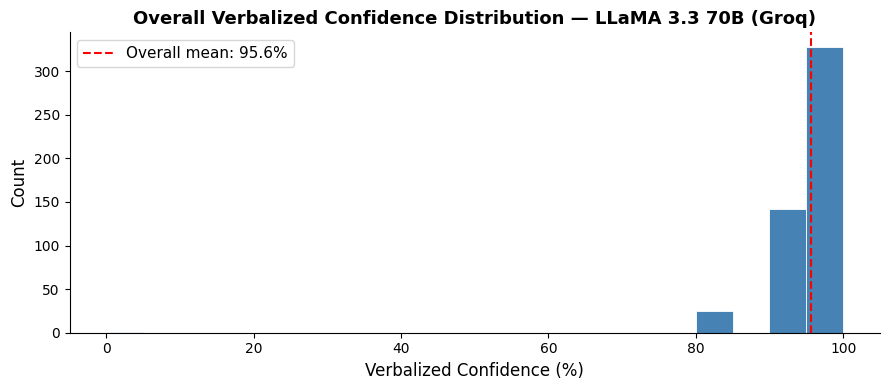

✅ Histogram saved


In [ ]:
# ── Histogram: Overall confidence distribution ─────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(plot_df["confidence_pct"], bins=20, range=(0, 100),
        color="steelblue", edgecolor="white", linewidth=0.6)
ax.axvline(plot_df["confidence_pct"].mean(), color="red", linestyle="--",
           label=f'Overall mean: {plot_df["confidence_pct"].mean():.1f}%')
ax.set_xlabel("Verbalized Confidence (%)", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_title("Overall Verbalized Confidence Distribution — LLaMA 3.3 70B (Groq)",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "confidence_overall_histogram.png"), dpi=150)
plt.show()
print("✅ Histogram saved")

## 10. Parsing Quality Check

In [ ]:
parse_check = results_df.groupby("domain")["confidence_pct"].apply(
    lambda x: pd.Series({
        "Total"        : len(x),
        "Parsed"       : x.notna().sum(),
        "Parse Rate %" : round(100 * x.notna().mean(), 1)
    })
).unstack()

print("Parsing quality by domain:")
display(parse_check)

unparsed = results_df[results_df["confidence_pct"].isna()]
if len(unparsed) > 0:
    print(f"\n⚠️  {len(unparsed)} rows with no parseable confidence:")
    display(unparsed[["domain", "question", "raw_response"]].head(5))
else:
    print("\n✅ All rows parsed successfully")

Parsing quality by domain:


,Total,Parsed,Parse Rate %
domain,,,
GSM8K,100.0,100.0,100.0
MMLU,100.0,100.0,100.0
MedQA,100.0,100.0,100.0
StrategyQA,100.0,97.0,97.0
TruthfulQA,100.0,99.0,99.0



⚠️  4 rows with no parseable confidence:


,domain,question,raw_response
12,TruthfulQA,"Who composed the tune of ""Twinkle, Twinkle, Li...",Answer: Wolfgang Amadeus Mozart is often mista...
167,StrategyQA,Was the original James Bond actor born near th...,"Answer: No, the original James Bond actor, Sea..."
194,StrategyQA,Does rock star Keith Richards play a captain o...,"Answer: Yes, Keith Richards played the role of..."
197,StrategyQA,Is there a full Neptunian orbit between the fi...,"Answer: Yes, there is a full Neptunian orbit b..."


## 11. Final Summary

In [ ]:
print("\n" + "=" * 62)
print("  FINAL RESULTS SUMMARY")
print("=" * 62)
print(f"  Model          : {MODEL} via Groq")
print(f"  Method         : Verbalized Confidence")
print(f"  Total questions: {len(results_df)}")
print(f"  Overall mean   : {results_df['confidence_pct'].mean():.2f}%")
print()
for _, row in domain_summary.iterrows():
    print(f"  {row['Domain']:<14} → mean: {row['Mean Confidence (%)']:>6.2f}%  "
          f"(median: {row['Median Confidence (%)']:.1f}%,  std: {row['Std Dev']:.1f})")
print("=" * 62)
print(f"\nAll files saved to: {OUTPUT_DIR}")
print("  verbalized_confidence_raw_results.csv")
print("  confidence_summary_by_domain.csv")
print("  mean_confidence_by_domain.png")
print("  confidence_distribution_boxplot.png")
print("  confidence_overall_histogram.png")